In [1]:
import math
import torch
import torch.version
import pandas as pd
import numpy as np
import chess
print(torch.version.__version__)

2.7.1+cu118


In [ ]:
df = pd.read_csv("C:\\Works\\chess-engine\\dataset\\chessData.csv")
df.head()


,FEN,Evaluation
0,rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...,-10
1,rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...,+56
2,rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...,-9
3,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...,+52
4,rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...,-26


In [2]:
import json
import torch
import matplotlib.pyplot as plt
 
# Import everything defined in your training script so
# NNUE, compute_metrics, HalfKPDataset etc. are all available
import importlib.util, sys
 
spec   = importlib.util.spec_from_file_location(
            "nnue_train",
            r"C:\Works\chess-engine\torch\nnue_train.py")   # ← your path
assert spec is not None, "no imports"
module = importlib.util.module_from_spec(spec)
assert spec.loader is not None, "no spec loader"
spec.loader.exec_module(module)
 
# Pull the names you need into this namespace
NNUE            = module.NNUE
compute_metrics = module.compute_metrics
HalfKPDataset   = module.HalfKPDataset
collate_halfkp  = module.collate_halfkp
 
print("Imports OK")
 

Imports OK


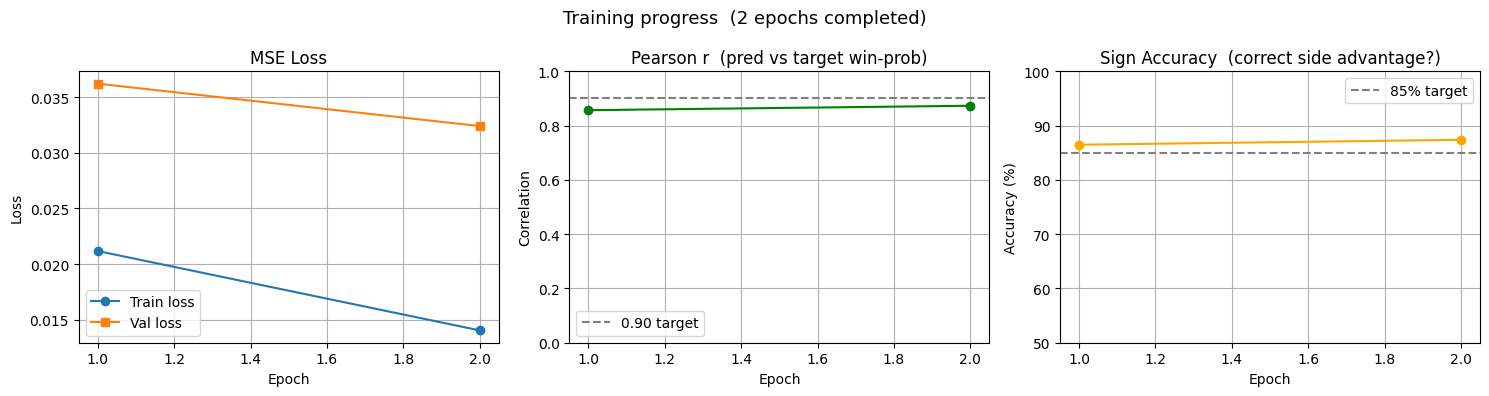

Last epoch — val_loss: 0.032398 | pearson_r: 0.8732 | sign_acc: 87.39%


In [3]:
with open(r"C:\Works\chess-engine\training_log_parquet.json") as f:
    history = json.load(f)
 
epochs_done = len(history['train_loss'])
x = list(range(1, epochs_done + 1))
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f"Training progress  ({epochs_done} epochs completed)", fontsize=13)
 
# ── Loss ─────────────────────────────────────────────────────
axes[0].plot(x, history['train_loss'], label='Train loss', marker='o')
axes[0].plot(x, history['val_loss'],   label='Val loss',   marker='s')
axes[0].set_title("MSE Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)
 
# What to look for:
#   Both curves falling          → model is learning
#   Val loss < train loss early  → normal (val set is easier)
#   Val loss rising, train falling → overfitting
 
# ── Pearson r ────────────────────────────────────────────────
axes[1].plot(x, history['pearson_r'], color='green', marker='o')
axes[1].set_title("Pearson r  (pred vs target win-prob)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Correlation")
axes[1].set_ylim(0, 1)
axes[1].axhline(0.90, color='gray', linestyle='--', label='0.90 target')
axes[1].legend()
axes[1].grid(True)
 
# What to look for:
#   Trending toward 0.90+        → good model
#   Stuck below 0.70             → check learning rate or data
 
# ── Sign accuracy ────────────────────────────────────────────
axes[2].plot(x, [v * 100 for v in history['sign_acc']], color='orange', marker='o')
axes[2].set_title("Sign Accuracy  (correct side advantage?)")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy (%)")
axes[2].set_ylim(50, 100)
axes[2].axhline(85, color='gray', linestyle='--', label='85% target')
axes[2].legend()
axes[2].grid(True)
 
# What to look for:
#   Above 85%                    → model reliably knows who is better
#   Stuck at ~50%                → model outputs are near-zero (dead network)
 
plt.tight_layout()
plt.savefig("training_curves.png", dpi=120)
plt.show()
print(f"Last epoch — val_loss: {history['val_loss'][-1]:.6f} | "
      f"pearson_r: {history['pearson_r'][-1]:.4f} | "
      f"sign_acc: {history['sign_acc'][-1]*100:.2f}%")

In [17]:
CHECKPOINT_PATH = r"C:\Works\chess-engine\nnue_epoch05.pt"  # ← change epoch number
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
 
model = NNUE()
model.load_state_dict(checkpoint['model_state'])
model.to(device)
model.eval()
 
print(f"Loaded checkpoint from epoch {checkpoint['epoch']}")
print(f"Val loss at that epoch : {checkpoint['val_loss']:.6f}")
 

Loaded checkpoint from epoch 5
Val loss at that epoch : 0.009800


In [18]:
import pandas as pd
from torch.utils.data import DataLoader
 
CSV_PATH  = r"C:\Works\chess-engine\dataset\chessData.csv"
VAL_SPLIT = 0.01
 
print("Reading validation slice from CSV…")
df      = pd.read_csv(CSV_PATH)
n_val   = int(len(df) * VAL_SPLIT)
df_val  = df.iloc[:n_val].reset_index(drop=True)
print(f"Validation rows: {len(df_val):,}")
 
ds_val = HalfKPDataset(df_val)
dl_val = DataLoader(
    ds_val,
    batch_size   = 4096,
    shuffle      = False,
    collate_fn   = collate_halfkp,
    num_workers  = 0,          # 0 is safe in Jupyter on Windows
)
 
metrics = compute_metrics(model, dl_val, device)
print(f"\nMetrics for epoch {checkpoint['epoch']} checkpoint")
print(f"  val_loss  : {metrics['val_loss']:.6f}")
print(f"  pearson_r : {metrics['pearson_r']:.4f}")
print(f"  sign_acc  : {metrics['sign_acc']*100:.2f}%")

Reading validation slice from CSV…
Validation rows: 129,580

Metrics for epoch 5 checkpoint
  val_loss  : 0.008224
  pearson_r : 0.7777
  sign_acc  : 79.78%


In [4]:
halfkp_features = module.halfkp_features
SCORE_SCALE     = module.SCORE_SCALE
 
def evaluate_fen(fen: str) -> float:
    """
    Returns the model's centipawn-equivalent score for a FEN.
    Positive = white is better, negative = black is better.
    """
    w_idx, b_idx, stm = halfkp_features(fen)
    
    w_flat = torch.tensor(w_idx, dtype=torch.long).unsqueeze(0).to(device)
    b_flat = torch.tensor(b_idx, dtype=torch.long).unsqueeze(0).to(device)
    # offsets for a single sample always start at 0
    w_off  = torch.zeros(1, dtype=torch.long).to(device)
    b_off  = torch.zeros(1, dtype=torch.long).to(device)
    stm_t  = torch.tensor([stm], dtype=torch.float32).to(device)
 
    with torch.no_grad():
       raw = model(w_flat.flatten(), w_off, b_flat.flatten(), b_off, stm_t)
 
    cp = raw.item()
    print(f"FEN   : {fen}")
    print(f"Score : {cp:+.1f} cp  ({'white' if cp > 0 else 'black'} is better)")
    return cp
 
# Starting position — should be near 0
evaluate_fen("rnbqkbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")
 
# White up a queen — should be strongly positive
evaluate_fen("rnb1kbnr/pppppppp/8/8/8/8/PPPPPPPP/RNBQKBNR w KQkq - 0 1")
 
# Black up a queen — should be strongly negative
evaluate_fen("rnbqkbnr/pppppppp/8/8/8/8/PPPP1PPP/RNBQKBNR w KQkq - 0 1")

NameError: name 'device' is not defined

Rows after filtering: 11,185,367  (removed 1,772,668 positions)


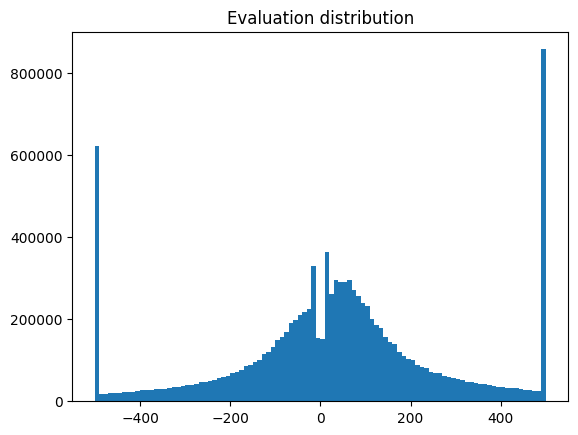

count    1.118537e+07
mean     4.030757e+01
std      3.416716e+02
min     -1.500000e+03
25%     -8.600000e+01
50%      3.800000e+01
75%      1.580000e+02
max      1.500000e+03
Name: Evaluation, dtype: float64


In [23]:
import matplotlib.pyplot as plt
df = pd.read_csv("C:\\Works\\chess-engine\\dataset\\chessData.csv")
parse_eval = module.parse_eval  
parsed = df["Evaluation"].apply(parse_eval)
mask = (parsed != 0.0) & (parsed.abs() <= 1500)
df = df[mask].reset_index(drop=True)
print(f"Rows after filtering: {len(df):,}  (removed {(~mask).sum():,} positions)")

evals = df['Evaluation'].apply(parse_eval)
evals_clipped = evals.clip(-500, 500)
plt.hist(evals_clipped, bins=100)
plt.title('Evaluation distribution')
plt.show()
print(evals.describe())